# Deploying SAM 3 for Promptable Segmentation

[SAM 3](https://github.com/facebookresearch/sam3) is Meta's foundation model for promptable
segmentation: instead of training a model per class, you prompt a single frozen model with
**text**, **points**, or **boxes** and it segments the object you mean.

This notebook wraps SAM 3 as a `DatamintModel`, deploys it, and runs remote inference.

## What you'll learn

1. Load SAM 3 and understand its two separate prompting APIs (text/grounding vs. point/box)
2. Wrap it in a `DatamintModel` adapter that speaks Datamint's `prompts` wire format
3. Test the adapter locally
4. Log, register, and deploy it
5. Run remote inference with text, point, and box prompts and visualize the masks

In this notebook we will focus on images only. However, SAM 3 also supports video.

## Prerequisites

```bash
pip install datamint
pip install torch torchvision  # CUDA build recommended, see SAM 3's own install docs
pip install 'git+https://github.com/facebookresearch/sam3.git'
```

SAM 3's checkpoints are gated on Hugging Face. Request access at
[huggingface.co/facebook/sam3](https://huggingface.co/facebook/sam3), then authenticate locally
(`hf auth login`) before running the cell that builds the model. A GPU is strongly recommended, as
SAM 3 is an 848M-parameter model and the deploy step below requests one (`with_gpu=True`).

## 0. Setup

In [1]:
from datamint import Api

PROJECT_NAME = 'SAM3_Prompt_Tutorial'
MODEL_NAME = PROJECT_NAME 

api = Api()
proj = api.projects.create(
    name=PROJECT_NAME,
    description='Tutorial: deploying SAM 3 for promptable segmentation',
    exists_ok=True,
)

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load SAM 3

In [2]:
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE != 'cuda':
    print('No CUDA device found - SAM 3 will run, but slowly. See the README for GPU setup.')
else:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast('cuda', dtype=torch.bfloat16).__enter__()

from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_model = build_sam3_image_model(device=DEVICE, enable_inst_interactivity=True)


def _unscript_sam2_transforms(model: torch.nn.Module) -> None:
    from sam3.model.utils.sam1_utils import SAM2Transforms
    from torchvision.transforms import Normalize, Resize

    for module in model.modules():
        if isinstance(module, SAM2Transforms):
            module.transforms = torch.nn.Sequential(
                Resize((module.resolution, module.resolution)),
                Normalize(module.mean, module.std),
            )


_unscript_sam2_transforms(sam3_model)
print(f'SAM 3 loaded on {DEVICE}')

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


SAM 3 loaded on cuda


## 2. Wrap SAM 3 in a `DatamintModel` Adapter


In [3]:
import numpy as np

from datamint.entities.annotations import ImageSegmentation
from datamint.mlflow.flavors.model import DatamintModel, ModelSettings
from datamint.mlflow.flavors.task_type import TaskType


class Sam3Adapter(DatamintModel):
    """Wraps SAM 3 for Datamint promptable-segmentation inference."""

    task_type = TaskType.IMAGE_SEGMENTATION

    def __init__(self, sam3_model, device: str = 'cpu') -> None:
        super().__init__(torch_model=sam3_model, settings=ModelSettings(need_gpu=True))
        self.device = device

    def predict_image(
        self,
        model_input: list,  # list[Resource]
        prompts: dict | None = None,
        **kwargs,
    ) -> list[list[ImageSegmentation]]:
        if not prompts:
            raise ValueError(
                'SAM 3 is a promptable model. Pass `prompts` with at least one of '
                'text, points, or boxes.'
            )

        model = self.get_pytorch_model()
        processor = Sam3Processor(model, device=self.device)
        results = []

        for resource in model_input:
            image = resource.fetch_file_data(auto_convert=True, use_cache=True)
            state = processor.set_image(image)
            annotations = []

            # --- Text prompt
            if 'text' in prompts:
                phrase = prompts['text']['text']
                state = processor.set_text_prompt(prompt=phrase, state=state)
                masks = state['masks'].squeeze(1).cpu().numpy()  # (N, H, W) bool
                for i, mask in enumerate(masks):
                    annotations.append(
                        ImageSegmentation(name=f'{phrase}_{i}', segmentation_data=mask.astype(np.uint8))
                    )

            # --- Point / box prompts
            if 'point' in prompts or 'box' in prompts:
                point_coords = np.array(prompts['point']['coordinates']) if 'point' in prompts else None
                point_labels = np.array(prompts['point']['labels']) if 'point' in prompts else None
                box = np.array(prompts['box']['boxes'][0]) if 'box' in prompts else None

                masks, scores, _ = model.predict_inst(
                    state,
                    point_coords=point_coords,
                    point_labels=point_labels,
                    box=box,
                    multimask_output=box is None,
                )
                best = masks[int(np.argmax(scores))]
                annotations.append(ImageSegmentation(name='object', segmentation_data=best.astype(np.uint8)))

            results.append(annotations)

        return results


adapter = Sam3Adapter(sam3_model, device=DEVICE)
print('Adapter ready.')

Adapter ready.


### 2.1 Smoke-test the adapter locally

We use `truck.jpg`, the image SAM 3's own examples use for point/box prompting
(`sam3/assets/images/truck.jpg`).

In [4]:
import requests

from datamint.entities.resource import LocalResource

TRUCK_IMAGE_URL = 'https://raw.githubusercontent.com/facebookresearch/sam3/main/assets/images/truck.jpg'

truck_bytes = requests.get(TRUCK_IMAGE_URL, timeout=30).content
truck_resource = LocalResource(raw_data=truck_bytes, filename='truck.jpg')

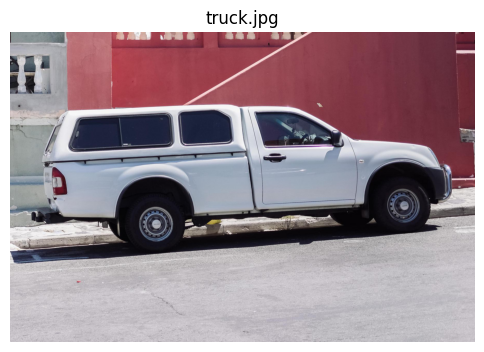

In [6]:
import io

from matplotlib import pyplot as plt
from PIL import Image

plt.figure(figsize=(6, 6))
plt.imshow(Image.open(io.BytesIO(truck_bytes)))
plt.axis('off')
plt.title('truck.jpg')
plt.show()

In [7]:
prompt_sets = {
    'text': {'text': {'text': 'wheel'}},
    'point': {'point': {'coordinates': [[500, 375]], 'labels': [1]}},
    'box': {'box': {'boxes': [[425, 600, 700, 875]]}},
}

local_preds = {}
for label, prompts in prompt_sets.items():
    preds = adapter.predict([truck_resource], params={'prompts': prompts})
    local_preds[label] = preds[0]
    print(f'{label:>6}: {len(preds[0])} mask(s) - {[a.name for a in preds[0]]}')

INFO:datamint.mlflow.flavors.prediction_router:Registering handler for 'slice' mode via delegation to 'image' handler
INFO:datamint.mlflow.flavors.prediction_router:Registering bridge handler for 'volume' mode (prereq: 'slice')
INFO:datamint.mlflow.flavors.prediction_router:Registering bridge handler for 'frame' mode (prereq: 'image')
INFO:datamint.mlflow.flavors.prediction_router:Registering bridge handler for 'all_frames' mode (prereq: 'image')
INFO:datamint.mlflow.flavors.prediction_router:Received prediction request with 1 resources and params {'prompts': {'text': {'text': 'wheel'}}} with mode 'image'
INFO:datamint.mlflow.flavors.prediction_router:Routing to 'image' mode for 1 resources
INFO:datamint.mlflow.flavors.prediction_router:Received prediction request with 1 resources and params {'prompts': {'point': {'coordinates': [[500, 375]], 'labels': [1]}}} with mode 'image'
INFO:datamint.mlflow.flavors.prediction_router:Routing to 'image' mode for 1 resources


  text: 4 mask(s) - ['wheel_0', 'wheel_1', 'wheel_2', 'wheel_3']


INFO:datamint.mlflow.flavors.prediction_router:Received prediction request with 1 resources and params {'prompts': {'box': {'boxes': [[425, 600, 700, 875]]}}} with mode 'image'
INFO:datamint.mlflow.flavors.prediction_router:Routing to 'image' mode for 1 resources


 point: 1 mask(s) - ['object']
   box: 1 mask(s) - ['object']


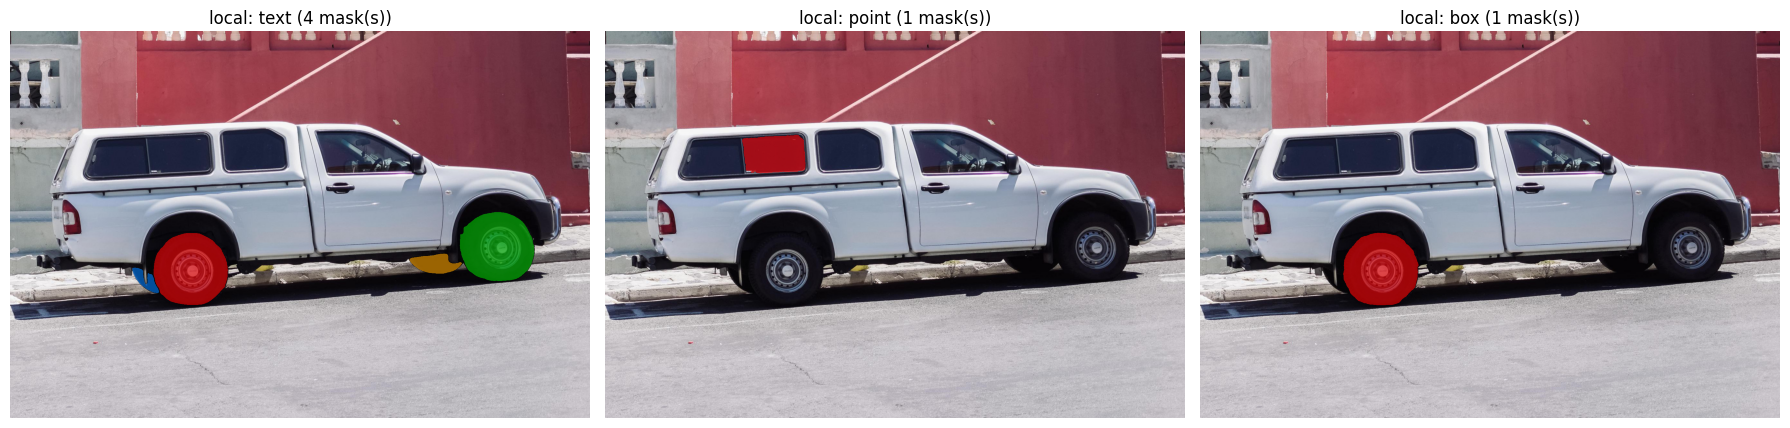

In [8]:
import io

import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

image_array = np.array(Image.open(io.BytesIO(truck_bytes)).convert('RGB'))

COLORS = [(255, 0, 0), (0, 200, 0), (0, 128, 255), (255, 165, 0)]


def mask_overlay(mask: np.ndarray, color: tuple, alpha: float = 0.6) -> np.ndarray:
    mask = np.asarray(mask, dtype=bool)
    overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
    overlay[mask] = (*color, int(alpha * 255))
    return overlay


fig, axes = plt.subplots(1, len(local_preds), figsize=(6 * len(local_preds), 6))
for ax, (label, annotations) in zip(axes, local_preds.items()):
    ax.imshow(image_array)
    for i, ann in enumerate(annotations):
        ax.imshow(mask_overlay(ann.mask, COLORS[i % len(COLORS)]))
    ax.set_title(f'local: {label} ({len(annotations)} mask(s))')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Log and Register the Model in MLflow

In [5]:
import tarfile
import tempfile
from pathlib import Path

import requests

SAM3_REF = 'main'
SAM3_TARBALL_URL = f'https://github.com/facebookresearch/sam3/archive/{SAM3_REF}.tar.gz'

sam3_src_dir = Path(tempfile.mkdtemp(prefix='sam3_src_'))
tarball_path = sam3_src_dir / 'sam3.tar.gz'
tarball_path.write_bytes(requests.get(SAM3_TARBALL_URL, timeout=60).content)

with tarfile.open(tarball_path) as tar:
    tar.extractall(sam3_src_dir)

SAM3_PACKAGE_DIR = sam3_src_dir / f'sam3-{SAM3_REF}' / 'sam3'
assert (SAM3_PACKAGE_DIR / '__init__.py').exists(), 'sam3 package not found where expected'
print(f'sam3 source ready for code_paths: {SAM3_PACKAGE_DIR}')

sam3 source ready for code_paths: /tmp/sam3_src_ammp9qgl/sam3-main/sam3


In [ ]:
import mlflow

import datamint.mlflow as datamint_mlflow
from datamint.mlflow.flavors import log_model

datamint_mlflow.set_project(PROJECT_NAME)
mlflow.set_experiment(PROJECT_NAME)

SAM3_RUNTIME_DEPS = [
    'timm>=1.0.17',
    'tqdm',
    'ftfy==6.1.1',
    'regex',
    'iopath>=0.1.10',
    'typing_extensions',
    'huggingface_hub',
    'einops',
    'pycocotools',
    'psutil',
]

with mlflow.start_run(run_name='sam3_deploy') as run:
    model_info = log_model(
        adapter,
        task_type=TaskType.IMAGE_SEGMENTATION,
        name='sam3_model',
        model_name=MODEL_NAME,
        code_paths=[str(SAM3_PACKAGE_DIR)],
        extra_pip_requirements=SAM3_RUNTIME_DEPS,
    )

print(f'Model URI : {model_info.model_uri}')
print(f'Run ID    : {run.info.run_id}')

### 3.1 Assign the `latest` alias

In [7]:
from mlflow import MlflowClient

MODEL_ALIAS = 'version-four'
client = MlflowClient()

versions = client.search_model_versions(f"name='{MODEL_NAME}'")
latest_version = max(versions, key=lambda v: int(v.version))

client.set_registered_model_alias(MODEL_NAME, MODEL_ALIAS, latest_version.version)
print(f"Alias '{MODEL_ALIAS}' -> version {latest_version.version}")

Alias 'version-four' -> version 4


## 4. Deploy to the Datamint Server

In [8]:
job = api.deploy.start(
    model_name=MODEL_NAME,
    model_alias=MODEL_ALIAS,
    with_gpu=True,
)

print('Deployment job started')
print(f'Job ID : {job.id}')

Deployment job started
Job ID : 127edb8d-ee72-456b-baaa-04bc491610e8


In [9]:
job.wait(on_status=lambda j: print(f'Status: {j.status}'))

if job.status == 'completed':
    print('Deployment successful!')
else:
    print(f'Deployment failed: {job.error_message}')
    print(job.build_logs)

Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: running
Status: 

## 5. Remote Inference with Prompts

In [ ]:
import io

from datamint.api.dto import BoxPrompt, InferencePrompts, PointPrompt

truck_buf = io.BytesIO(truck_bytes)
truck_buf.name = 'truck.jpg'

r = api.resources.upload_resource(
    truck_buf,
    mimetype='image/jpeg',
    tags=['sam3-demo'],
    publish_to=proj,
)

INFO:user_logger:"truck.jpg" uploaded
INFO:user_logger:Adding resources to project


In [21]:
print(r)
jobs = {
    'text': api.inference.predict_image(
        MODEL_NAME, model_alias=MODEL_ALIAS, resource_id=r,
        prompts=InferencePrompts(text='wheel'),
    ),
    #'point': api.inference.predict_image(
    #    MODEL_NAME, model_alias=MODEL_ALIAS, resource_id=r,
    #    prompts=InferencePrompts(points=[PointPrompt(label=1, x=500, y=375)]),
    #),
    #'box': api.inference.predict_image(
    #    MODEL_NAME, model_alias=MODEL_ALIAS, resource_id=r,
    #    prompts=InferencePrompts(boxes=[BoxPrompt(x_min=425, y_min=600, x_max=700, y_max=875)]),
    #),
}

for label, job in jobs.items():
    job.wait()
    print(label, job.status, job.error_message)
    
    
    #job.wait()
    #print(f'{label:>6}: {len(job.predictions[0])} mask(s)')

84b473cf-7267-435a-9d33-a22ed038e5d6


text failed Failed to start model pod: Pod operation failed for image sam3_prompt_tutorial:version-four: Pod 58496671669ec29f51a21f0a7a195ead7c2fa9e3508c8e5057de23f71f4e2dc8 failed health check after 60.3s. Last error: HTTPConnectionPool(host='127.0.0.1', port=5001): Max retries exceeded with url: /ping (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fa4e750dc30>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
fig, axes = plt.subplots(1, len(jobs), figsize=(6 * len(jobs), 6))
for ax, (label, job) in zip(axes, jobs.items()):
    ax.imshow(image_array)
    for i, ann in enumerate(job.predictions[0]):
        ax.imshow(mask_overlay(ann.mask, COLORS[i % len(COLORS)]))
    ax.set_title(f'prompt: {label} ({len(job.predictions[0])} mask(s))')
    ax.axis('off')

plt.tight_layout()
plt.show()